# **Customer Churn Prediction**

**Problem Statement**

The telecom industry faces a growing challenge of customer churn, where customers discontinue their services and switch to competitors, resulting in significant revenue loss. This project aims to analyze a telecom company's customer dataset — containing demographic details, account information, and service usage patterns — to build a **Machine Learning-based classification model** that can accurately predict which customers are likely to churn. By identifying at-risk customers in advance, the company can take proactive, data-driven retention actions such as offering personalized discounts, redesigning contract plans, and improving service quality, ultimately reducing churn rate and improving customer satisfaction.

**Objectives**

The objective of this task is to:

● Understand and explore the customer dataset

● Perform data preprocessing (missing values, duplicates, outliers)

● Conduct Exploratory Data Analysis (EDA)

● Apply encoding and feature scaling

● Train multiple classification algorithms

● Evaluate models using classification metrics

● Perform cross-validation and hyperparameter tuning

● Select the best-performing model

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

**Load Dataset**

In [ ]:
df = pd.read_csv("telecom_churn_data (1).csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


**Basic checks**

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


In [ ]:
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7041.000000
mean,0.162147,32.371149,64.749581
std,0.368612,24.559481,30.085731
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7038 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7041 non-null   object 


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


In [ ]:
#missing values
df.isnull().sum()

,0
customerID,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Drop customerID (not useful)
df.drop(columns=['customerID'], inplace=True)

In [ ]:
# Convert TotalCharges to numeric (some values are blank strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

**Handeling missing values**

In [ ]:
# Fill missing categorical columns with mode
df['gender'].fillna(df['gender'].mode()[0], inplace=True)
df['PaperlessBilling'].fillna(df['PaperlessBilling'].mode()[0], inplace=True)

/tmp/ipykernel_1149/4061216096.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].fillna(df['gender'].mode()[0], inplace=True)
/tmp/ipykernel_1149/4061216096.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [ ]:
# Fill missing numerical columns with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['MonthlyCharges'].fillna(df['MonthlyCharges'].median(), inplace=True)

/tmp/ipykernel_1149/1813952191.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
/tmp/ipykernel_1149/1813952191.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after:", df.duplicated().sum())
print("Dataset shape after cleaning:", df.shape)

Duplicates before: 22
Duplicates after: 0
Dataset shape after cleaning: (7021, 20)


# **EDA**

**Univariate Analysis**

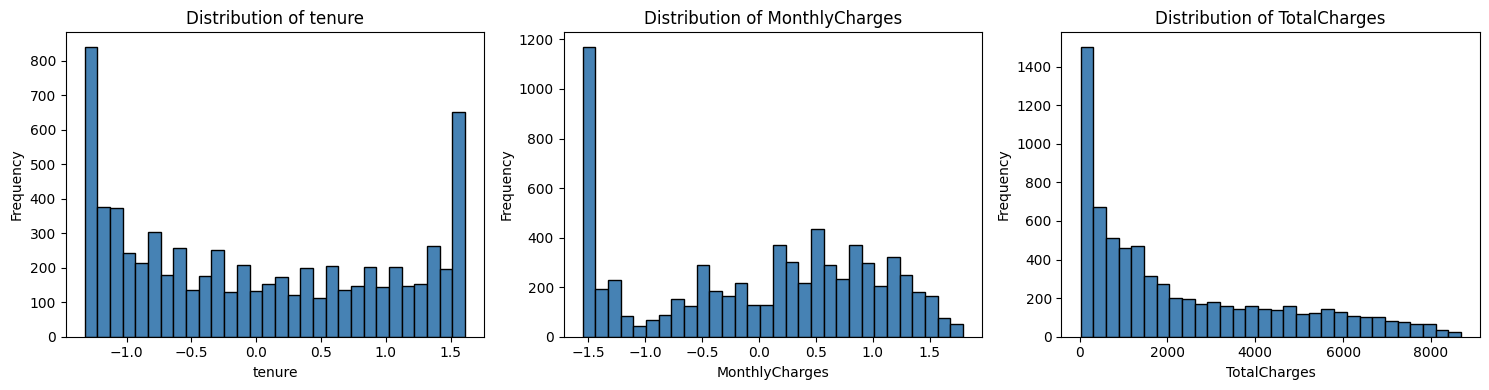

In [ ]:
#Distribution of Numerical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


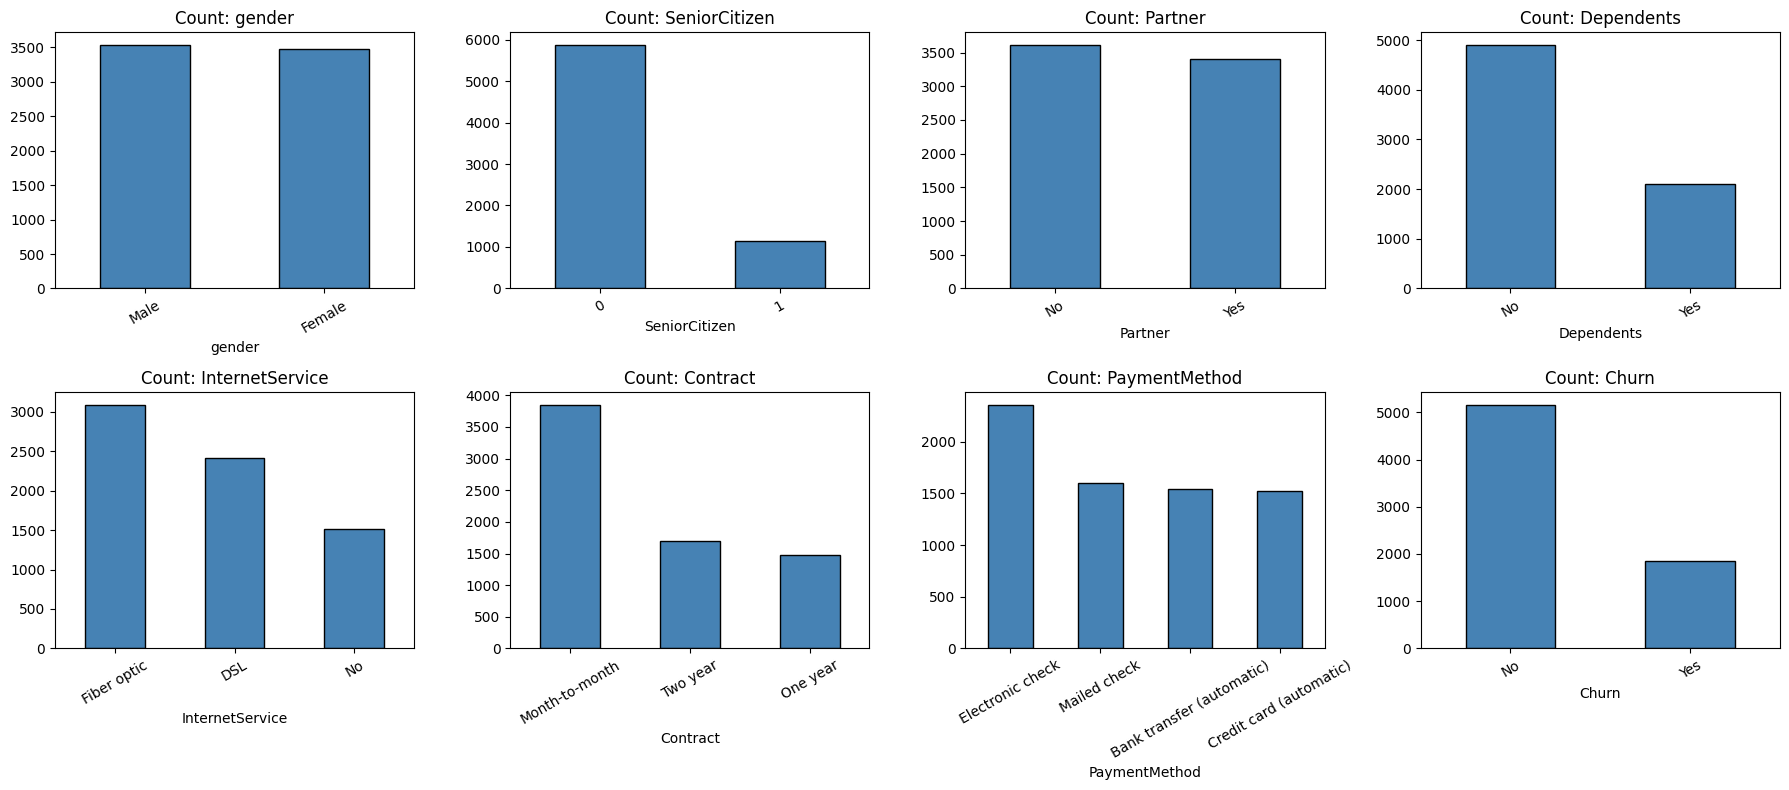

In [ ]:
#countplots for Categorical Columns
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'InternetService', 'Contract', 'PaymentMethod', 'Churn']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Count: {col}')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Bivariate Analysis**

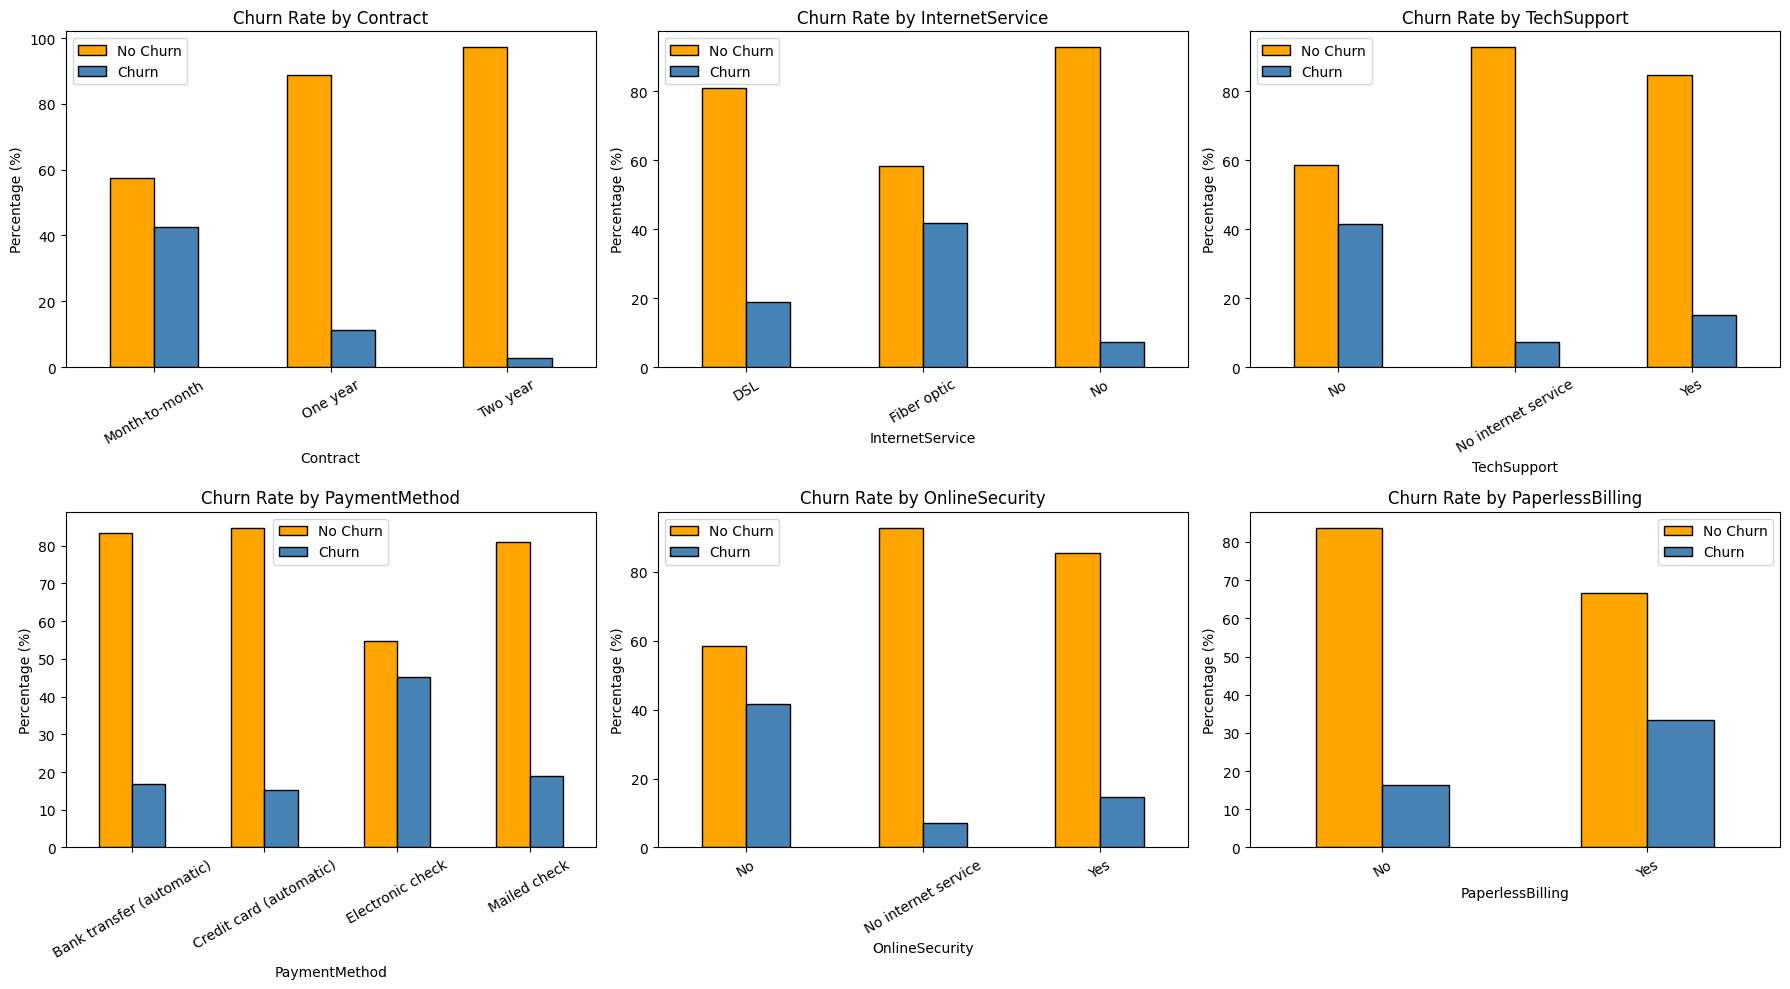

In [ ]:
# Churn rate by categorical features
cat_bivariate = ['Contract', 'InternetService', 'TechSupport',
                 'PaymentMethod', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_bivariate):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['orange', 'steelblue'], edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

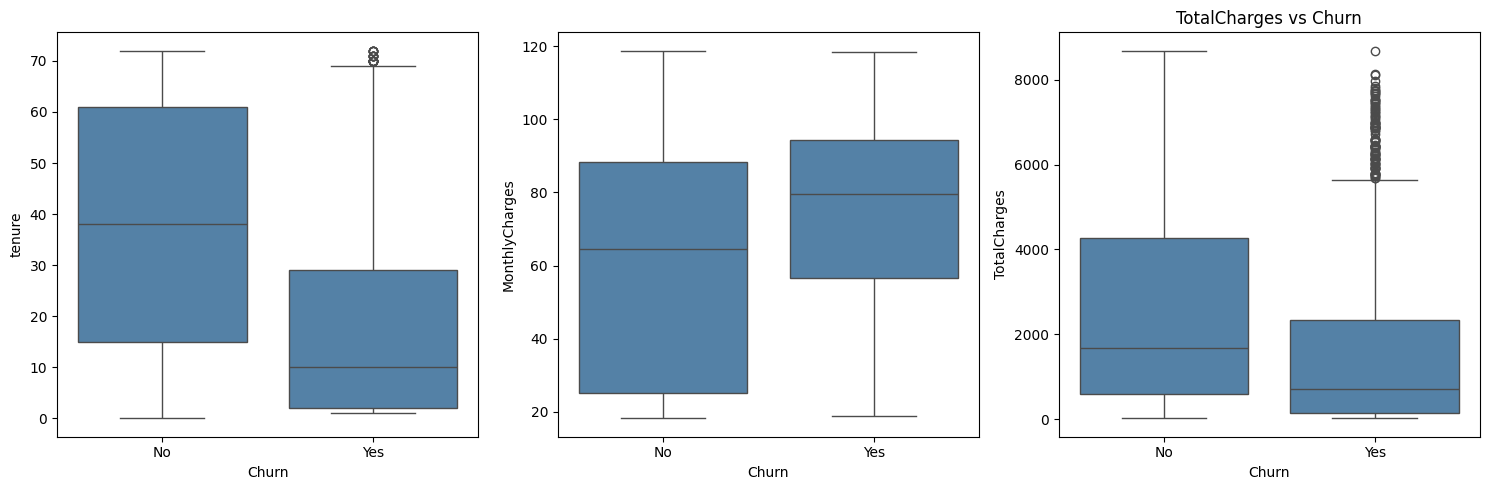

In [ ]:
#Churn Rate by Numerical Features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(
        x='Churn',
        y=col,
        data=df,
        ax=axes[i],
        color='steelblue'
    )
axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

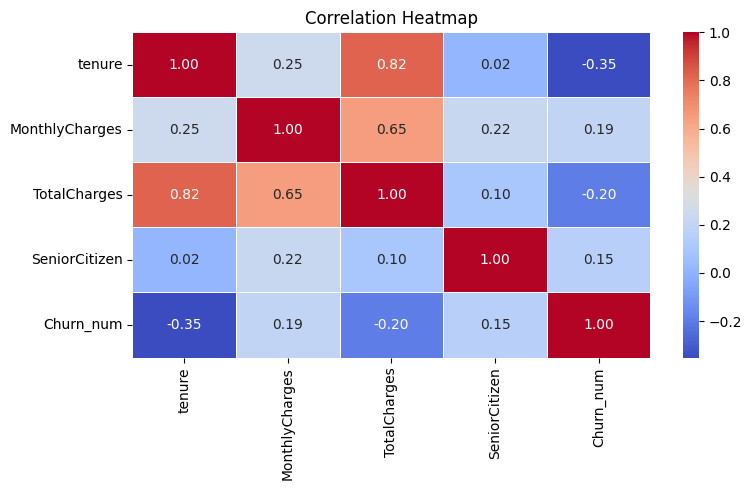

In [ ]:
#correlation Heatmap
df_corr = df.copy()
df_corr['Churn_num'] = (df_corr['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(8, 5))
corr = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_num']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Detecting and Handleing the outliers**

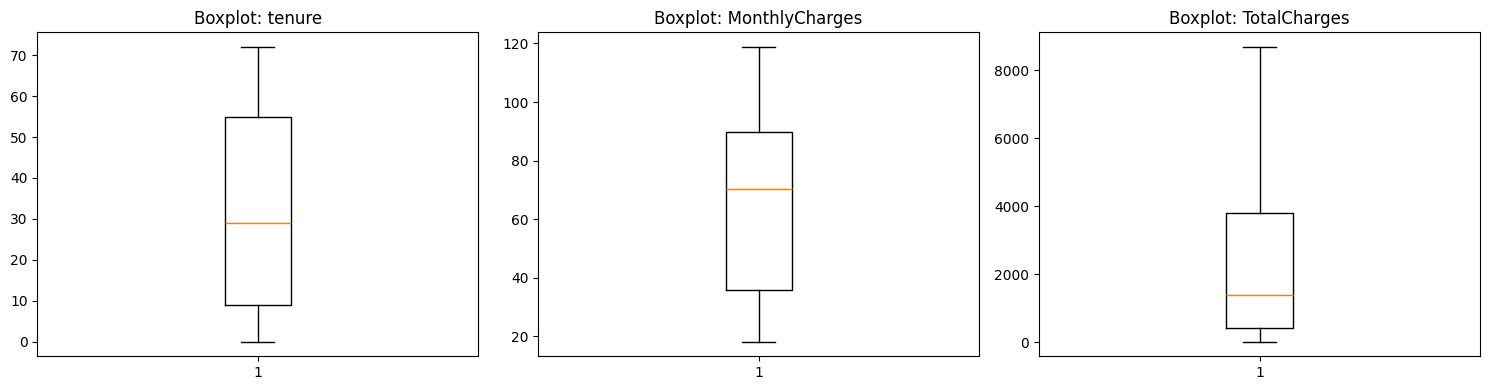

In [ ]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Visualize outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

In [ ]:
# outliers using IQR method
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers} outliers")
    df[col] = df[col].clip(lower=lower, upper=upper)

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


**Encoding**

In [ ]:
# Label Encoding for binary columns
le = LabelEncoder()
df_encoded = df.copy()
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [ ]:
# One-Hot Encoding for multi-class columns
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

**Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
model = StandardScaler()
df[['tenure']]=model.fit_transform(df[['tenure']])
df[['MonthlyCharges']]=model.fit_transform(df[['MonthlyCharges']])
df[['Totalcharges']]=model.fit_transform(df[['TotalCharges']])

**Separate Features and Target**

In [ ]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

In [ ]:
print("Features (X) shape:", X.shape)
print("Target  (y) shape: ", y.shape)
print("\nClass distribution:")
print(y.value_counts())

Features (X) shape: (7021, 30)
Target  (y) shape:  (7021,)

Class distribution:
Churn
0    5164
1    1857
Name: count, dtype: int64


**Train Test split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:    ", X_test.shape)

Training set: (5616, 30)
Testing set:     (1405, 30)


**Handeling Imbalance Data**



In [ ]:
from imblearn.over_sampling import SMOTE
import numpy as np

print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("After  SMOTE:", dict(zip(*np.unique(y_train_sm, return_counts=True))))

Before SMOTE: {np.int64(0): np.int64(4131), np.int64(1): np.int64(1485)}
After  SMOTE: {np.int64(0): np.int64(4131), np.int64(1): np.int64(4131)}


**Training Classifiction Model**

In [ ]:
models = {
    "Logistic Regression":  LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors":  KNeighborsClassifier(n_neighbors=5),
    "Decision Tree":        DecisionTreeClassifier(random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42),
    "SVC":                  SVC(probability=True, random_state=42),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost":              XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                          random_state=42, verbosity=0)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Model Evaluation**

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)

    results.append([name, acc, pre, rec, f1, roc])

    print(f"\n{name}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
Confusion Matrix:
 [[934  99]
 [180 192]]

K-Nearest Neighbors
Confusion Matrix:
 [[905 128]
 [213 159]]

Decision Tree
Confusion Matrix:
 [[835 198]
 [193 179]]

Random Forest
Confusion Matrix:
 [[928 105]
 [203 169]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



SVC
Confusion Matrix:
 [[1033    0]
 [ 372    0]]

Gradient Boosting
Confusion Matrix:
 [[942  91]
 [189 183]]

XGBoost
Confusion Matrix:
 [[913 120]
 [191 181]]


**HyperParameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# GridSearchCV - Random Forest
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params, cv=3, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_sm, y_train_sm)
print("Best RF Params:", rf_grid.best_params_)
print("Best RF F1:    ", round(rf_grid.best_score_, 4))

# RandomizedSearchCV - XGBoost
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.9, 1.0]
}
xgb_rand = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                  random_state=42, verbosity=0),
    xgb_params, n_iter=10, cv=3, scoring='f1',
    n_jobs=-1, random_state=42
)
xgb_rand.fit(X_train_sm, y_train_sm)
print("\nBest XGB Params:", xgb_rand.best_params_)
print("Best XGB F1:    ", round(xgb_rand.best_score_, 4))

best_rf  = rf_grid.best_estimator_
best_xgb = xgb_rand.best_estimator_

Best RF Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best RF F1:     0.815

Best XGB Params: {'subsample': 0.7, 'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.01}
Best XGB F1:     0.8037


**Comaprision of the model**

In [ ]:
result_df = pd.DataFrame(results, columns=[
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'
])
print("\nModel Comparison:\n")
print(result_df)


Model Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.801423   0.659794  0.516129  0.579186  0.710146
1  K-Nearest Neighbors  0.757295   0.554007  0.427419  0.482549  0.651754
2        Decision Tree  0.721708   0.474801  0.481183  0.477971  0.644754
3        Random Forest  0.780783   0.616788  0.454301  0.523220  0.676328
4                  SVC  0.735231   0.000000  0.000000  0.000000  0.500000
5    Gradient Boosting  0.800712   0.667883  0.491935  0.566563  0.701921
6              XGBoost  0.778648   0.601329  0.486559  0.537890  0.685196


**Best Model**

In [ ]:
best_row = result_df.iloc[0]
print(f" Best Model: {best_row['Model']}")
print(f"   Accuracy:  {best_row['Accuracy']}")
print(f"   Precision: {best_row['Precision']}")
print(f"   Recall:    {best_row['Recall']}")
print(f"   F1 Score:  {best_row['F1 Score']}")
print(f"   ROC-AUC:   {best_row['ROC-AUC']}")

 Best Model: Logistic Regression
   Accuracy:  0.801423487544484
   Precision: 0.6597938144329897
   Recall:    0.5161290322580645
   F1 Score:  0.579185520361991
   ROC-AUC:   0.7101458326827592


**Key Insights**


KEY FACTORS DRIVING CHURN:

  1.Month-to-month contracts → Highest churn rate

   2. High monthly charges → More likely to churn

   3. No tech support / online security → Higher churn

   4. New customers (short tenure) → Higher risk

   5. Fiber optic internet → More churn than DSL

   6. Electronic check payment → Associated with churn

BUSINESS RECOMMENDATIONS:

   1. Offer incentives to switch from monthly to annual contracts

   2. Bundle tech support & security for at-risk customers

   3. Give loyalty discounts to high monthly charge customers

   4. Launch onboarding programs for first 6 months

   5. Promote auto-payment (credit card / bank transfer)

   6. Use model to flag high-risk customers every month proactively
